In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("Mall_Customers.csv")
print(df.head())
print(df.info())
print(df.isnull().sum())


   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None
CustomerID                0
Genre                  

In [5]:
from sklearn.preprocessing import StandardScaler
x=df[['Annual Income (k$)',
      'Spending Score (1-100)']]
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

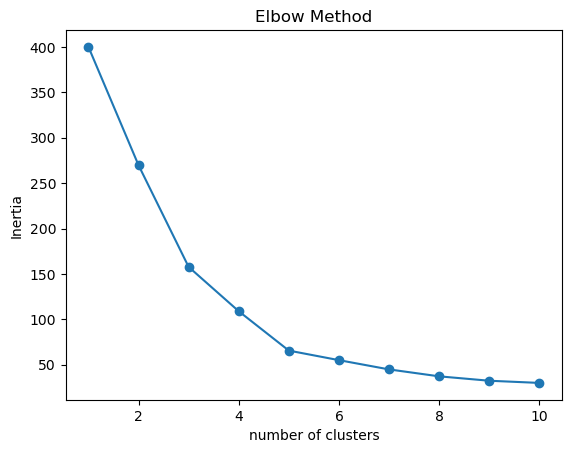

In [8]:
from sklearn.cluster import KMeans
inertias=[]
for k in range(1,11):
    model=KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10,
    )
    model.fit(x_scaled)
    inertias.append(model.inertia_)
plt.plot(range(1,11),inertias,marker='o')
plt.xlabel("number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()
  

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


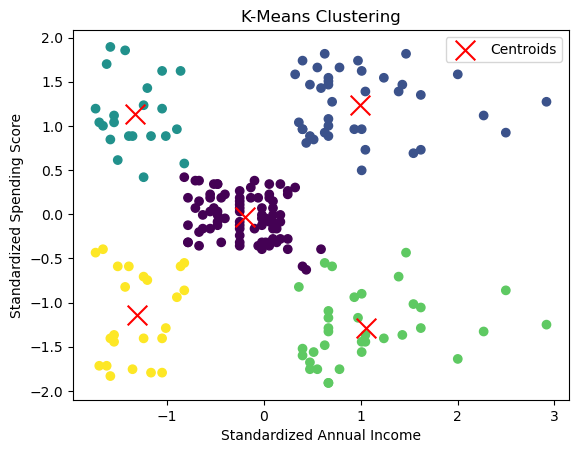

In [11]:
k=5
kmeans=KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)
kmeans_labels=kmeans.fit_predict(x_scaled)
plt.scatter(
    x_scaled[:,0],
    x_scaled[:,1],
    c=kmeans_labels,
    cmap='viridis'
)
plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    c='red',
    marker='x',
    s=200,
    label='Centroids'
)
plt.xlabel("Standardized Annual Income")
plt.ylabel("Standardized Spending Score")
plt.title("K-Means Clustering")
plt.legend()
plt.show()
    

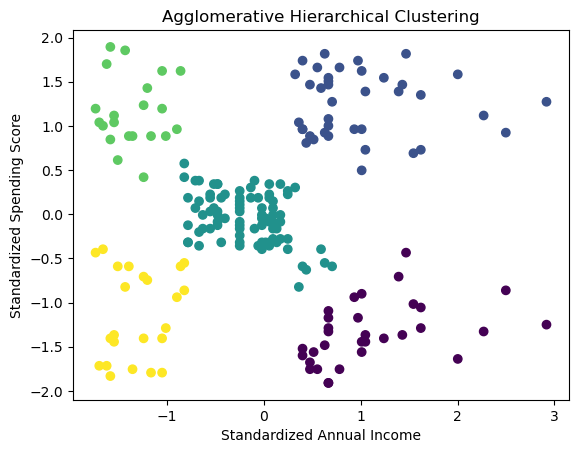

In [13]:
from sklearn.cluster import AgglomerativeClustering
hierarchical=AgglomerativeClustering(
    n_clusters=k,
    linkage='ward'
)
hierarchical_labels=(
    hierarchical.fit_predict(x_scaled)
)
plt.scatter(
    x_scaled[:,0],
    x_scaled[:,1],
    c=hierarchical_labels,
    cmap='viridis'
)
plt.xlabel("Standardized Annual Income")
plt.ylabel("Standardized Spending Score")
plt.title("Agglomerative Hierarchical Clustering")
plt.show()

In [ ]:
from scipy.cluster.hierarchy import(
   linkage,dendogram
)
linked=linkage(x_scaled,method='ward')
plt.figure(figsize=(12,5))
dendogram(linked)
plt.title("Hierarchical clustering dendogram")
plt.xlabe;
